--- KROK 1: PRZYGOTOWANIE DANYCH ---


Saving pokemon.csv to pokemon (3).csv

--- KROK 2: ANALIZA PCA I K-MEANS ---


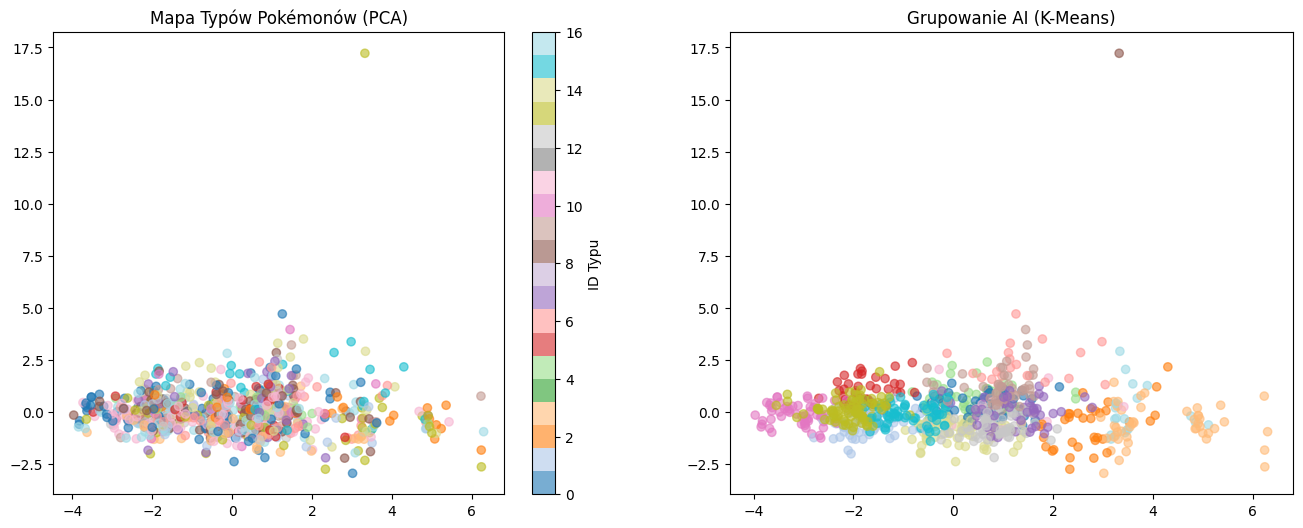


--- KROK 3: PORÓWNANIE MODELI ---
Logistic Regression Accuracy: 0.2625
Random Forest Accuracy: 0.2188
Gradient Boosting Accuracy: 0.1875


/tmp/ipython-input-1037308172.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(results.keys()), y=list(results.values()), palette='viridis')


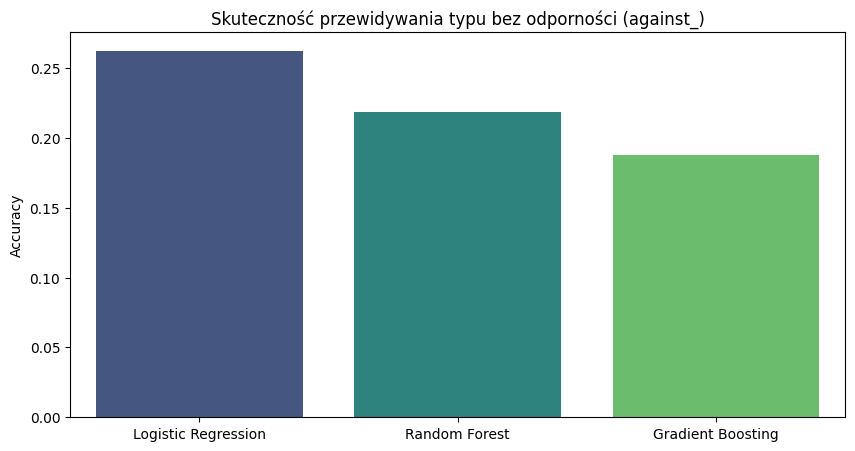


--- RAPORT KLASYFIKACJI ---
              precision    recall  f1-score   support

         bug       0.31      0.36      0.33        14
        dark       0.00      0.00      0.00         6
      dragon       0.43      0.60      0.50         5
    electric       0.25      0.12      0.17         8
       fairy       0.00      0.00      0.00         4
    fighting       0.40      0.33      0.36         6
        fire       0.00      0.00      0.00        10
       ghost       0.00      0.00      0.00         5
       grass       0.21      0.25      0.23        16
      ground       0.20      0.17      0.18         6
         ice       0.00      0.00      0.00         5
      normal       0.34      0.48      0.40        21
      poison       0.00      0.00      0.00         6
     psychic       0.17      0.09      0.12        11
        rock       0.11      0.11      0.11         9
       steel       0.00      0.00      0.00         5
       water       0.18      0.30      0.23        2

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


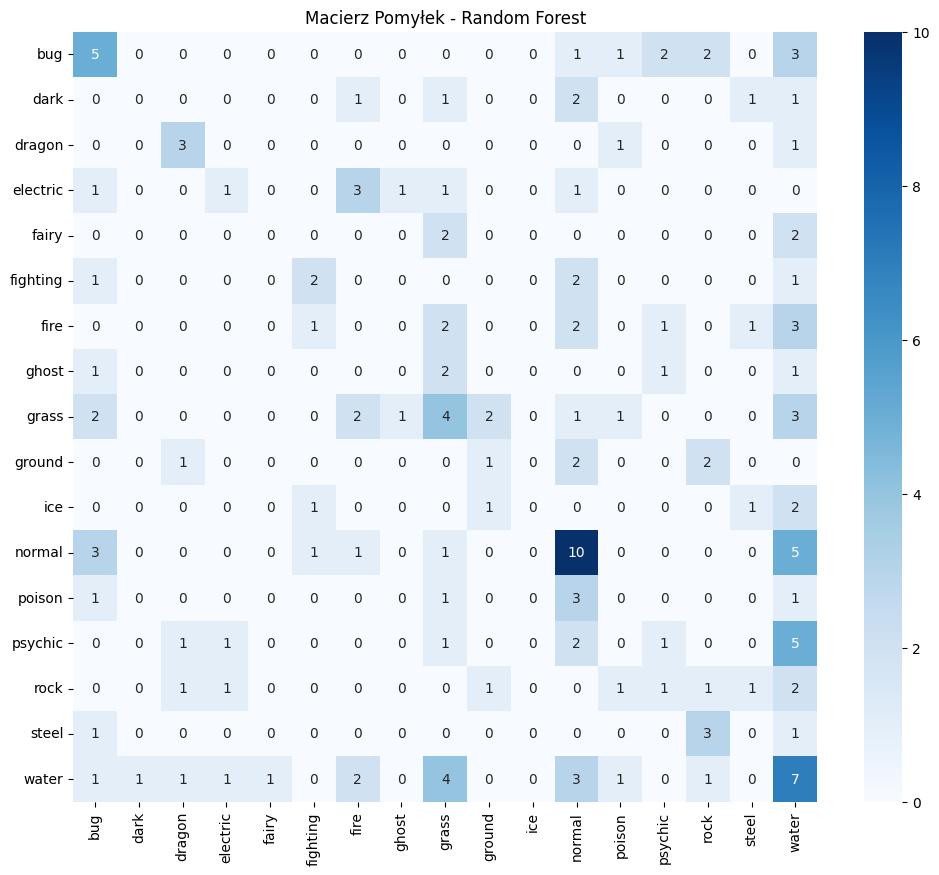

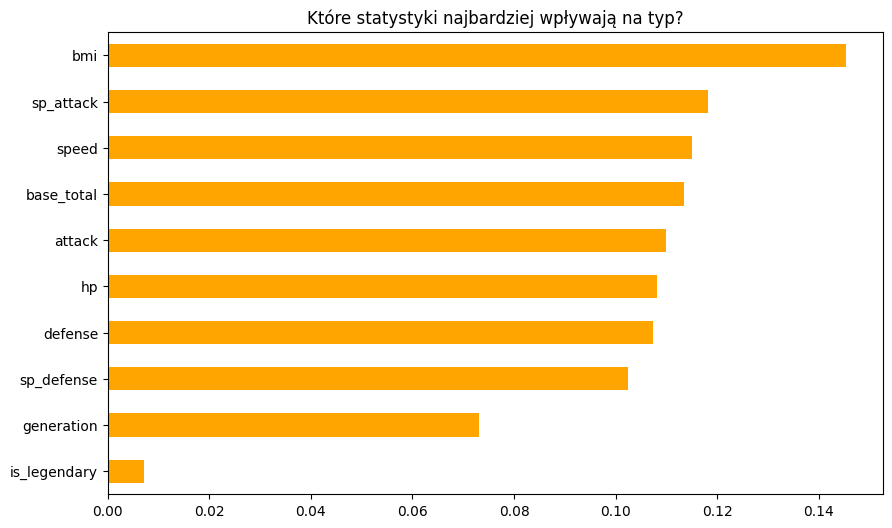


--- KROK 5: EKSPORT MODELI ---
Pobieranie plików... Załącz je w folderze ze swoją aplikacją Streamlit!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from google.colab import files

# =================================================================
# 1. ŁADOWANIE I INŻYNIERIA CECH
# =================================================================
print("--- KROK 1: PRZYGOTOWANIE DANYCH ---")
uploaded = files.upload()
df = pd.read_csv(list(uploaded.keys())[0])

# Czyszczenie i nowe cechy
df = df[df['type1'] != 'flying']
df['height_m'] = df['height_m'].fillna(df['height_m'].median())
df['weight_kg'] = df['weight_kg'].fillna(df['weight_kg'].median())
df['bmi'] = df['weight_kg'] / (df['height_m']**2 + 1)

# DEFINICJA CECH DLA APLIKACJI
features_app = ['hp', 'attack', 'defense', 'sp_attack', 'sp_defense', 'speed', 'base_total', 'bmi', 'is_legendary', 'generation']

X = df[features_app]
le = LabelEncoder()
y = le.fit_transform(df['type1'])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# =================================================================
# 2. WIZUALIZACJA I KLASTRYZACJA (Zrozumienie danych)
# =================================================================
print("\n--- KROK 2: ANALIZA PCA I K-MEANS ---")
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

kmeans = KMeans(n_clusters=len(le.classes_), random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)



fig, ax = plt.subplots(1, 2, figsize=(16, 6))
# Wykres Typów
scatter1 = ax[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='tab20', alpha=0.6)
ax[0].set_title('Mapa Typów Pokémonów (PCA)')
fig.colorbar(scatter1, ax=ax[0], label='ID Typu')

# Wykres Klastrów
scatter2 = ax[1].scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='tab20', alpha=0.6)
ax[1].set_title('Grupowanie AI (K-Means)')
plt.show()

# =================================================================
# 3. PORÓWNANIE MODELI
# =================================================================
print("\n--- KROK 3: PORÓWNANIE MODELI ---")
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test))
    results[name] = acc
    print(f"{name} Accuracy: {acc:.4f}")

# Wykres skuteczności
plt.figure(figsize=(10, 5))
sns.barplot(x=list(results.keys()), y=list(results.values()), palette='viridis')
plt.title('Skuteczność przewidywania typu bez odporności (against_)')
plt.ylabel('Accuracy')
plt.show()

# =================================================================
# 4. SZCZEGÓŁOWA ANALIZA RANDOM FOREST
# =================================================================
best_model = models["Random Forest"]
y_pred = best_model.predict(X_test)

print("\n--- RAPORT KLASYFIKACJI ---")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Macierz pomyłek
plt.figure(figsize=(12, 10))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d',
            xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')
plt.title('Macierz Pomyłek - Random Forest')
plt.show()



# Ważność cech
importances = pd.Series(best_model.feature_importances_, index=features_app).sort_values(ascending=True)
plt.figure(figsize=(10, 6))
importances.plot(kind='barh', color='orange')
plt.title('Które statystyki najbardziej wpływają na typ?')
plt.show()

# =================================================================
# 5. EKSPORT DO APLIKACJI
# =================================================================
print("\n--- KROK 5: EKSPORT MODELI ---")
joblib.dump(best_model, 'pokemon_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(le, 'label_encoder.pkl')
joblib.dump(features_app, 'features_list.pkl')

print("Pobieranie plików...")
files.download('pokemon_model.pkl')
files.download('scaler.pkl')
files.download('label_encoder.pkl')
files.download('features_list.pkl')